In [1]:
import os
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

import constants as k
import paths as p
import utils
from paths import ONE_DRIVE_DIR, FIGURES_DIR
from raster_plot import plot_raster

In [2]:
data_dir = '/Users/rebekahzhang/data/neural_data'
pickle_dir = Path(os.path.join(data_dir, 'session_pickles'))
figure_dir = os.path.join(data_dir, 'figures')

units_vetted = pd.read_csv(os.path.join(data_dir,'logs', 'units_vetted.csv'), index_col=0).sort_values('unit_id')
sessions_vetted = pd.read_csv(os.path.join(data_dir, 'logs', 'sessions_vetted.csv'), index_col=0).sort_values('num_units')

In [9]:
units_qc_all = pd.read_csv(p.LOGS_DIR / "qc_per_unit_with_pass_flags.csv")
units_qc = units_qc_all[units_qc_all['qc_pass_all'] == True]

# make df

In [10]:
events, trials, spikes = utils.get_data_for_debugging(units_vetted)

In [11]:
trials['good_trial'] = (~trials['missed']) & (trials['num_bg_repeat'] == 0)

In [12]:
def compute_period_firing_rates(trials, spikes):
    period_fr_list = []
    for _, trial in trials.iterrows():
        trial_id = trial['trial_id']
        subject = trial['subject']
        session_datetime = trial['session_datetime']
        trial_spikes = spikes[spikes['trial_id'] == trial_id]
        bg_spikes = trial_spikes[trial_spikes['period'] == 'background']
        wait_spikes = trial_spikes[trial_spikes['period'] == 'wait']
        cons_spikes = trial_spikes[trial_spikes['period'] == 'consumption']
        bg_len = trial['background_length']
        wait_len = trial['wait_length']
        cons_len = trial['consumption_length']
        bg_fr = len(bg_spikes) / bg_len if bg_len > 0 else np.nan
        wait_fr = len(wait_spikes) / wait_len if wait_len > 0 else np.nan
        cons_fr = len(cons_spikes) / cons_len if cons_len > 0 else np.nan
        period_fr_list.append({
            'trial_id': trial_id,
            'subject': subject,
            'session_datetime': session_datetime,
            'background_fr': bg_fr,
            'wait_fr': wait_fr,
            'consumption_fr': cons_fr
        })
    period_fr = pd.DataFrame(period_fr_list)
    return period_fr

In [13]:
period_fr = compute_period_firing_rates(trials, spikes)

TAKES 10 MIN! DO NOT RE-RUN! I REPEAT DO NOT RE-RUN!

In [15]:
# all_unit_trial_fr = []

# units_by_session = units_vetted.groupby("session_id")
# for session_id, session_units in units_by_session:
#     events, trials, units = utils.get_session_data(session_id)
#     region = session_units['region'].iloc[0]
#     for _, unit_info in session_units.iterrows():
#         unit_id = unit_info['unit_id']
#         spikes = units[unit_info['id']]
#         period_fr = compute_period_firing_rates(trials, spikes)
#         # Add identifying columns
#         period_fr['session_id'] = session_id
#         period_fr['unit_id'] = unit_id
#         period_fr['region'] = region
#         # Append to list
#         all_unit_trial_fr.append(period_fr)

# # Concatenate all results into one DataFrame
# all_unit_trial_fr_df = pd.concat(all_unit_trial_fr, ignore_index=True)
# all_unit_trial_fr_df.to_csv(os.path.join(data_dir, 'all_unit_trial_fr_df.csv'), index=False)

# Analyze df

using only units passed all qc for now. didnt regenerate the big df

In [19]:
units_qc_all = pd.read_csv(p.LOGS_DIR / "qc_per_unit_with_pass_flags.csv")
units_qc = units_qc_all[units_qc_all['qc_pass_all'] == True]

In [ ]:
all_unit_trial_fr_df = pd.read_csv(os.path.join(data_dir, 'all_unit_trial_fr_df.csv'))
all_unit_trial_fr_df = all_unit_trial_fr_df[all_unit_trial_fr_df['unit_id'].isin(units_qc['unit_id'])]

In [36]:
results = []
for unit_id, unit_df in all_unit_trial_fr_df.groupby('unit_id'):
    # Only keep trials present in all three periods
    valid_trials = unit_df.dropna(subset=['background_fr', 'wait_fr', 'consumption_fr'])
    bg = valid_trials['background_fr']
    wait = valid_trials['wait_fr']
    cons = valid_trials['consumption_fr']
    # Only run test if all periods have >1 value
    if len(wait) > 1:
        stat_bg, p_bg = stats.ttest_rel(wait, bg)
        stat_cons, p_cons = stats.ttest_rel(wait, cons)
        stat_rest, p_rest = stats.ttest_rel(bg, cons)
        results.append({
            'unit_id': unit_id,
            'wait_vs_bg_p': p_bg,
            'wait_vs_cons_p': p_cons,
            'bg_vs_cons_p': p_rest,
            'wait_mean': wait.mean(),
            'bg_mean': bg.mean(),
            'cons_mean': cons.mean()
        })

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(data_dir, 'interval_keeping_stats_per_unit.csv'), index=False)

In [ ]:
interval_keepers = results_df[(results_df['wait_vs_bg_p'] < 0.001) & (results_df['wait_vs_cons_p'] < 0.001)].copy()
interval_keepers['mean_diff'] = (
    abs(interval_keepers['wait_mean'] - interval_keepers['bg_mean']) +
    abs(interval_keepers['wait_mean'] - interval_keepers['cons_mean'])
)
interval_keepers_sorted = interval_keepers.sort_values('mean_diff', ascending=False)

In [23]:
# Merge region info into interval_keepers
interval_keepers_sorted = pd.merge(
    interval_keepers_sorted,
    units_vetted[['unit_id', 'region']],
    on='unit_id',
    how='left'
)
# Now you can group by region
interval_keepers_by_region = interval_keepers_sorted.groupby("region")

In [24]:
interval_keepers_top_by_region = interval_keepers_sorted.groupby("region")
for region, region_data in interval_keepers_top_by_region:
    source_folder = ONE_DRIVE_DIR / 'raster_plots' / 'raster_histo_to_decision_by_wait_length' / region
    destination_folder = FIGURES_DIR / 'interval_keeper_units' / region
    os.makedirs(destination_folder, exist_ok=True)
    print(f"Processing region: {region}")
    print(f"Destination folder: {destination_folder}")
    for _, unit_data in region_data.iterrows():
        unit_id = unit_data['unit_id']
        source_path = source_folder / f"{unit_id}.png"
        destination_path = destination_folder / f"{unit_id}.png"
        try:
            shutil.copy2(source_path, destination_path)
        except FileNotFoundError:
            print(f"Warning: Source file not found - {source_path}")
        except Exception as e:
            print(f"Error copying {source_path}: {str(e)}")

Processing region: str
Destination folder: /Users/rebekahzhang/data/neural_data/figures/interval_keeper_units/str
Processing region: v1
Destination folder: /Users/rebekahzhang/data/neural_data/figures/interval_keeper_units/v1
Processing region: v1
Destination folder: /Users/rebekahzhang/data/neural_data/figures/interval_keeper_units/v1


In [41]:
interval_keepers_strict = results_df[(results_df['wait_vs_bg_p'] < 0.05) & (results_df['wait_vs_cons_p'] < 0.05) & (results_df['bg_vs_cons_p'] > 0.05)].copy()
interval_keepers_strict['mean_diff'] = (
    abs(interval_keepers_strict['wait_mean'] - interval_keepers_strict['bg_mean']) +
    abs(interval_keepers_strict['wait_mean'] - interval_keepers_strict['cons_mean'])
)
interval_keepers_sorted_strict = interval_keepers_strict.sort_values('mean_diff', ascending=False)
# Merge region info into interval_keepers
interval_keepers_sorted_strict = pd.merge(
    interval_keepers_sorted_strict,
    units_vetted[['unit_id', 'region']],
    on='unit_id',
    how='left'
)

for region, region_data in interval_keepers_sorted_strict.groupby("region"):
    source_folder = ONE_DRIVE_DIR / 'raster_plots' / 'raster_histo_to_decision_by_wait_length' / region
    destination_folder = FIGURES_DIR / 'interval_keeper_units_strict' / region
    os.makedirs(destination_folder, exist_ok=True)
    print(f"Processing region: {region}")
    print(f"Destination folder: {destination_folder}")
    for _, unit_data in region_data.iterrows():
        unit_id = unit_data['unit_id']
        source_path = source_folder / f"{unit_id}.png"
        destination_path = destination_folder / f"{unit_id}.png"
        try:
            shutil.copy2(source_path, destination_path)
        except FileNotFoundError:
            print(f"Warning: Source file not found - {source_path}")
        except Exception as e:
            print(f"Error copying {source_path}: {str(e)}")

Processing region: str
Destination folder: /Users/rebekahzhang/data/neural_data/figures/interval_keeper_units_strict/str
Processing region: v1
Destination folder: /Users/rebekahzhang/data/neural_data/figures/interval_keeper_units_strict/v1


In [26]:
interval_keepers_sorted

,unit_id,wait_vs_bg_p,wait_vs_cons_p,wait_mean,bg_mean,cons_mean,mean_diff,region
0,RZ036_2024-07-12_str_unit-127,3.100954e-14,1.596797e-64,25.620661,51.234560,102.790379,102.783616,str
1,RZ038_2024-07-18_str_unit-84,5.406285e-27,3.924691e-90,4.045219,19.505780,44.782975,56.198316,str
2,RZ057_2025-03-15_str_unit-112,8.570163e-43,3.977832e-32,51.053288,26.997454,79.435891,52.438437,str
3,RZ037_2024-07-17_str_unit-108,4.566665e-53,9.829800e-34,41.290286,13.998106,19.128126,49.454340,str
4,RZ057_2025-03-14_str_unit-111,5.730407e-21,8.056885e-56,60.331585,45.072642,91.289057,46.216415,str
...,...,...,...,...,...,...,...,...
936,RZ065_2025-02-21_v1_unit-235,2.396055e-18,8.786012e-08,0.312417,0.722345,0.116917,0.605428,v1
937,RZ059_2025-03-20_v1_unit-253,8.581239e-18,2.645306e-14,0.340357,0.613032,0.630800,0.563118,v1
938,RZ063_2025-03-05_str_unit-135,2.079049e-04,9.765089e-06,0.664946,0.457174,0.408742,0.463977,str
939,RZ050_2024-11-21_str_unit-153,2.351125e-04,9.074359e-04,0.618680,0.862764,0.786029,0.411432,str


In [28]:
units_qc = units_qc.copy()
units_qc.loc[:, 'interval_keeper'] = units_qc['unit_id'].isin(interval_keepers_sorted['unit_id'])

In [29]:
units_qc

,session_id,datetime,mouse,region,insertion_number,unit_id,firing_rate,snr,presence_ratio,isi_violation,...,qc_pass_amplitude_cutoff,qc_pass_presence_ratio,qc_pass_isolation_distance,qc_pass_snr,qc_pass_contamination_rate,qc_pass_all.1,qc_pass_snr_ampcut,qc_pass_max_drift,qc_pass_cumulative_drift,interval_keeper
0,RZ034_2024-07-13_str,2024-07-13 12:58:26,RZ034,str,1,RZ034_2024-07-13_str_unit-7,3.020480,8.26081,1.000000,0.000000,...,True,True,True,True,True,True,True,True,True,True
1,RZ034_2024-07-13_str,2024-07-13 12:58:26,RZ034,str,1,RZ034_2024-07-13_str_unit-8,0.694021,10.37970,0.904762,0.000000,...,True,True,True,True,True,True,True,False,False,False
3,RZ034_2024-07-13_str,2024-07-13 12:58:26,RZ034,str,1,RZ034_2024-07-13_str_unit-14,5.418220,8.12457,1.000000,0.004447,...,True,True,True,True,True,True,True,True,True,False
4,RZ034_2024-07-13_str,2024-07-13 12:58:26,RZ034,str,1,RZ034_2024-07-13_str_unit-16,3.447000,9.80236,1.000000,0.065926,...,True,True,True,True,True,True,True,True,True,False
5,RZ034_2024-07-13_str,2024-07-13 12:58:26,RZ034,str,1,RZ034_2024-07-13_str_unit-19,3.732520,9.56258,1.000000,0.009371,...,True,True,True,True,True,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3588,RZ065_2025-02-22_str,2025-02-22 13:03:06,RZ065,str,1,RZ065_2025-02-22_str_unit-554,0.736120,12.22500,0.931818,0.115252,...,True,True,True,True,True,True,True,False,False,False
3592,RZ065_2025-02-22_str,2025-02-22 13:03:06,RZ065,str,1,RZ065_2025-02-22_str_unit-571,0.551575,5.45079,0.863636,0.205275,...,True,True,True,True,True,True,True,False,False,False
3593,RZ065_2025-02-22_str,2025-02-22 13:03:06,RZ065,str,1,RZ065_2025-02-22_str_unit-579,4.425710,6.97512,1.000000,0.063769,...,True,True,True,True,True,True,True,True,True,True
3597,RZ065_2025-02-22_str,2025-02-22 13:03:06,RZ065,str,1,RZ065_2025-02-22_str_unit-608,0.723005,21.31910,0.829545,0.358413,...,True,True,True,True,True,True,True,False,False,False


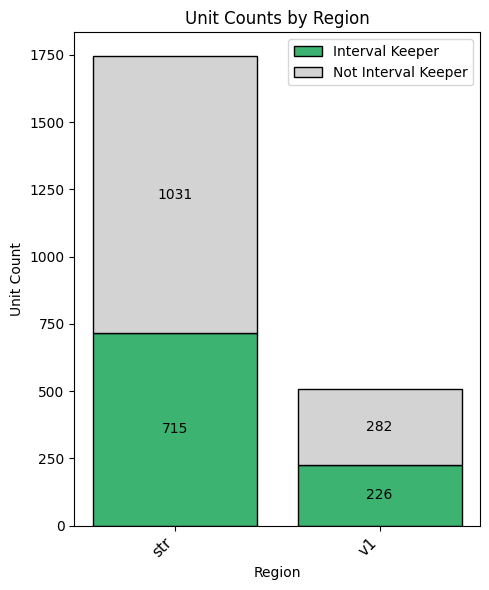

In [83]:
# Bar plot: total units and interval_keeper units per region
region_counts = units_qc.groupby(['region', 'interval_keeper']).size().unstack(fill_value=0)
x = range(len(region_counts))
fig, ax = plt.subplots(figsize=(5, 6))
bars_keeper = ax.bar(x, region_counts[True], label='Interval Keeper', color='mediumseagreen', edgecolor='black')
bars_nonkeeper = ax.bar(x, region_counts[False], bottom=region_counts[True], label='Not Interval Keeper', color='lightgray', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(region_counts.index, rotation=45, ha='right', fontsize=11)
ax.set_title('Unit Counts by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Unit Count')
# Value labels
for bar in bars_keeper + bars_nonkeeper:
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{int(height)}',
                ha='center', va='center', color='black')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'interval_keeper_unit_counts_by_region.png', dpi=300)

# example unit

In [75]:
def plot_unit_raster_and_boxplot(events, trials, spikes, anchor, sorter, 
                                 all_unit_trial_fr_df, unit_id, xlim=(-4, 2), show_figure=False):
    _, axes = plt.subplots(2, 1, figsize=(6, 10), gridspec_kw={'height_ratios': [3, 2]})
    ax1 = axes[0]
    plot_raster(ax1, events, trials, spikes, anchor, sorter, show_legend=False)
    ax1.set_xlim(xlim)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Trial")

    ax2 = axes[1]
    unit_data = all_unit_trial_fr_df.loc[all_unit_trial_fr_df['unit_id'] == unit_id]
    boxplot_data = [
        unit_data['background_fr'].dropna(),
        unit_data['wait_fr'].dropna(),
        unit_data['consumption_fr'].dropna()
    ]
    ax2.boxplot(boxplot_data, tick_labels=['Background', 'Wait', 'Consumption'])
    ax2.set_ylabel('Firing Rate (Hz)')

    plt.tight_layout()
    if show_figure:
        plt.show()
    plt.savefig(os.path.join(p.FIGURES_DIR, f"unit_raster_boxplot_{unit_id}.png"), dpi=300)
    plt.close()

In [76]:
anchor = k.TO_DECISION
sorter = k.WAIT_LENGTH

session_id = 'RZ062_2025-03-05_v1'
unit_num = 118
unit_id = f"{session_id}_unit-{unit_num}"
events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id=session_id, unit_id=unit_num)
plot_unit_raster_and_boxplot(events, trials, spikes, anchor, sorter, all_unit_trial_fr_df, unit_id)

In [77]:
session_id = 'RZ063_2025-03-06_v1'
unit_num = 81
xlim = (-8, 2)
unit_id = f"{session_id}_unit-{unit_num}"
events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id=session_id, unit_id=unit_num)
plot_unit_raster_and_boxplot(events, trials, spikes, anchor, sorter, all_unit_trial_fr_df, unit_id, xlim=xlim)

In [78]:
session_id = 'RZ059_2025-03-21_v1'
unit_num = 227
xlim = (-20, 2)
unit_id = f"{session_id}_unit-{unit_num}"
events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id=session_id, unit_id=unit_num)
plot_unit_raster_and_boxplot(events, trials, spikes, anchor, sorter, all_unit_trial_fr_df, unit_id, xlim=xlim)

In [79]:
session_id = 'RZ051_2024-11-20_v1'
unit_num = 87
xlim = (-20, 2)
unit_id = f"{session_id}_unit-{unit_num}"
events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id=session_id, unit_id=unit_num)
plot_unit_raster_and_boxplot(events, trials, spikes, anchor, sorter, all_unit_trial_fr_df, unit_id, xlim=xlim)

In [80]:
session_id = 'RZ053_2024-10-22_v1'
unit_num = 107
xlim = (-20, 2)
unit_id = f"{session_id}_unit-{unit_num}"
events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id=session_id, unit_id=unit_num)
plot_unit_raster_and_boxplot(events, trials, spikes, anchor, sorter, all_unit_trial_fr_df, unit_id, xlim=xlim)

In [81]:
session_id = 'RZ053_2024-10-25_v1'
unit_num = 14
xlim = (-20, 2)
unit_id = f"{session_id}_unit-{unit_num}"
events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id=session_id, unit_id=unit_num)
plot_unit_raster_and_boxplot(events, trials, spikes, anchor, sorter, all_unit_trial_fr_df, unit_id, xlim=xlim)

In [82]:
session_id = 'RZ063_2025-03-04_v1'
unit_num = 125
xlim = (-8, 2)
unit_id = f"{session_id}_unit-{unit_num}"
events, trials, spikes = utils.get_data_for_debugging(units_vetted, session_id=session_id, unit_id=unit_num)
plot_unit_raster_and_boxplot(events, trials, spikes, anchor, sorter, all_unit_trial_fr_df, unit_id, xlim=xlim)